# Cardiovascular Disease — Exploratory Data Analysis (EDA)

**Dataset:** `cardio_train.csv` — 70,000 patient records, 13 columns.
This notebook is the EDA stage for the clinical intelligence system. The goal of EDA here is not just to "look at the data" but to answer four questions before any modelling:

1. **Structure** — what are the rows, columns, types, and grain of the data?
2. **Quality** — what is missing, duplicated, or *clinically impossible*?
3. **Distributions** — what does each variable look like on its own?
4. **Signal** — how does each variable relate to the target (`cardio`)?

> The `cardio_train.csv` columns and their meaning:
>
> | column | meaning | notes |
> |---|---|---|
> | `id` | record id | drop for analysis |
> | `age` | age **in days** | convert to years |
> | `gender` | 1 = women, 2 = men | categorical |
> | `height` | height in cm | |
> | `weight` | weight in kg | |
> | `ap_hi` | systolic BP | **known to contain bad values** |
> | `ap_lo` | diastolic BP | **known to contain bad values** |
> | `cholesterol` | 1 normal, 2 above, 3 well above | ordinal |
> | `gluc` | glucose: 1 normal, 2 above, 3 well above | ordinal |
> | `smoke` | smoker (0/1) | binary |
> | `alco` | alcohol intake (0/1) | binary |
> | `active` | physically active (0/1) | binary |
> | `cardio` | **target** — has CVD (0/1) | binary |


## 1. Setup

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

RANDOM_STATE = 42

## 2. Load the data

This file is **semicolon-separated** (`;`).

Point `DATA_PATH` at wherever your file lives.

In [8]:
DATA_PATH = "../data/raw/cardio_train.csv"   # e.g. "/mnt/user-data/uploads/cardio_train.csv"

def load_cardio(path):
    df = pd.read_csv(path, sep=";")
    if df.shape[1] == 1:                 # wrong delimiter -> fell into one column
        df = pd.read_csv(path, sep=",")
    return df

df = load_cardio(DATA_PATH)
print(f"Loaded shape: {df.shape}")
df.head()


Loaded shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## 3. Structure: shape, types, and a first look

In [9]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


In [10]:
# Tail too — sometimes junk hides at the end of a file
df.tail()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1
69999,99999,20540,1,170,72.0,120,80,2,1,0,0,1,0


In [11]:
# Numeric summary. 'age' is in days, so the numbers look odd until we convert.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


### Read the `describe()` output like a clinician, not a statistician

Even before plotting, scan the `min`/`max` rows for **physically impossible values**:

- `ap_hi` (systolic) and `ap_lo` (diastolic) will show absurd min/max (negative numbers, values in the thousands). Real BP roughly lives in 60–250 (systolic) and 40–200 (diastolic) mmHg.
- `height` min/max may include people ~50 cm or ~250 cm.
- `weight` may include values near 0 or implausibly high.

These are the headline data-quality problems in this dataset, and EDA's job is to surface them.

## 4. Data quality checks

In [12]:
# 4a. Missing values
missing = df.isna().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() else "None")

Missing values per column:
None


In [13]:
# 4b. Duplicates. 'id' should be unique; full-row duplicates would be a red flag.
print("Duplicate ids        :", df["id"].duplicated().sum())
print("Fully duplicated rows:", df.drop(columns="id").duplicated().sum())

Duplicate ids        : 0
Fully duplicated rows: 24


In [14]:
# Drop the id column for analysis — it carries no signal.
df = df.drop(columns="id")

## 5. Feature engineering for interpretability

Three transforms make the data readable: age in years, BMI, and decoded category labels. We keep the raw columns and add readable companions.

In [15]:
# Age: days -> years
df["age_years"] = (df["age"] / 365.25).round(1)

# BMI = kg / m^2
df["bmi"] = (df["weight"] / (df["height"] / 100) ** 2).round(1)

# Human-readable label maps (for plotting only; keep numeric cols for modelling)
gender_map = {1: "women", 2: "men"}
level_map  = {1: "normal", 2: "above normal", 3: "well above normal"}
binary_map = {0: "no", 1: "yes"}

df["gender_lbl"]      = df["gender"].map(gender_map)
df["cholesterol_lbl"] = df["cholesterol"].map(level_map)
df["gluc_lbl"]        = df["gluc"].map(level_map)
df[["age_years", "bmi", "gender_lbl", "cholesterol_lbl"]].head()

#df.head()

,age_years,bmi,gender_lbl,cholesterol_lbl
0,50.4,22.0,men,normal
1,55.4,34.9,women,well above normal
2,51.6,23.5,women,well above normal
3,48.2,28.7,men,normal
4,47.8,23.0,women,normal


## 6. Univariate analysis — one variable at a time

### 6a. Continuous variables

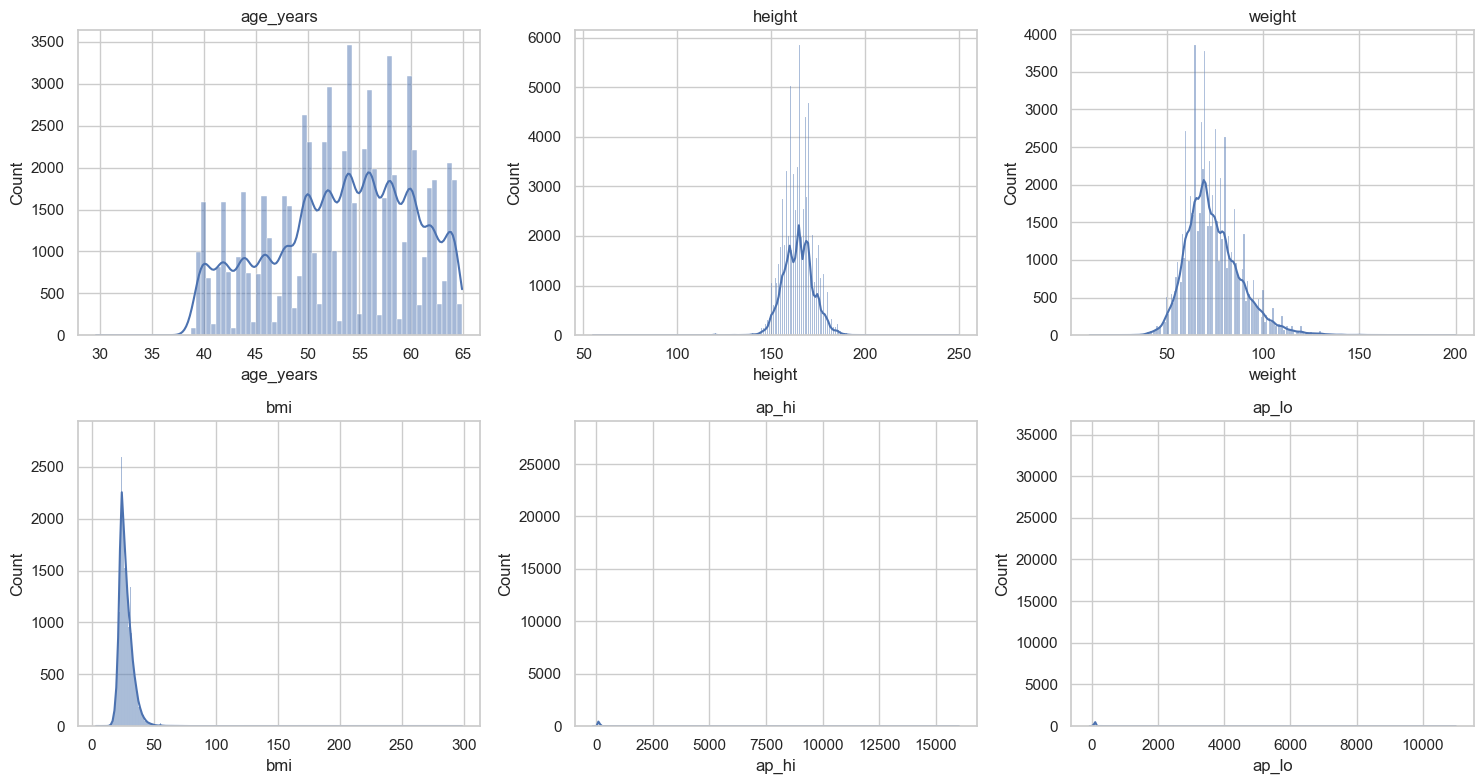

In [16]:
continuous = ["age_years", "height", "weight", "bmi", "ap_hi", "ap_lo"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), continuous):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Note how `ap_hi` and `ap_lo` are almost unreadable — a handful of extreme values stretch the x-axis so the real distribution collapses into one bar. That *is* the finding: the BP columns are contaminated with bad data.

### 6b. Categorical / binary variables

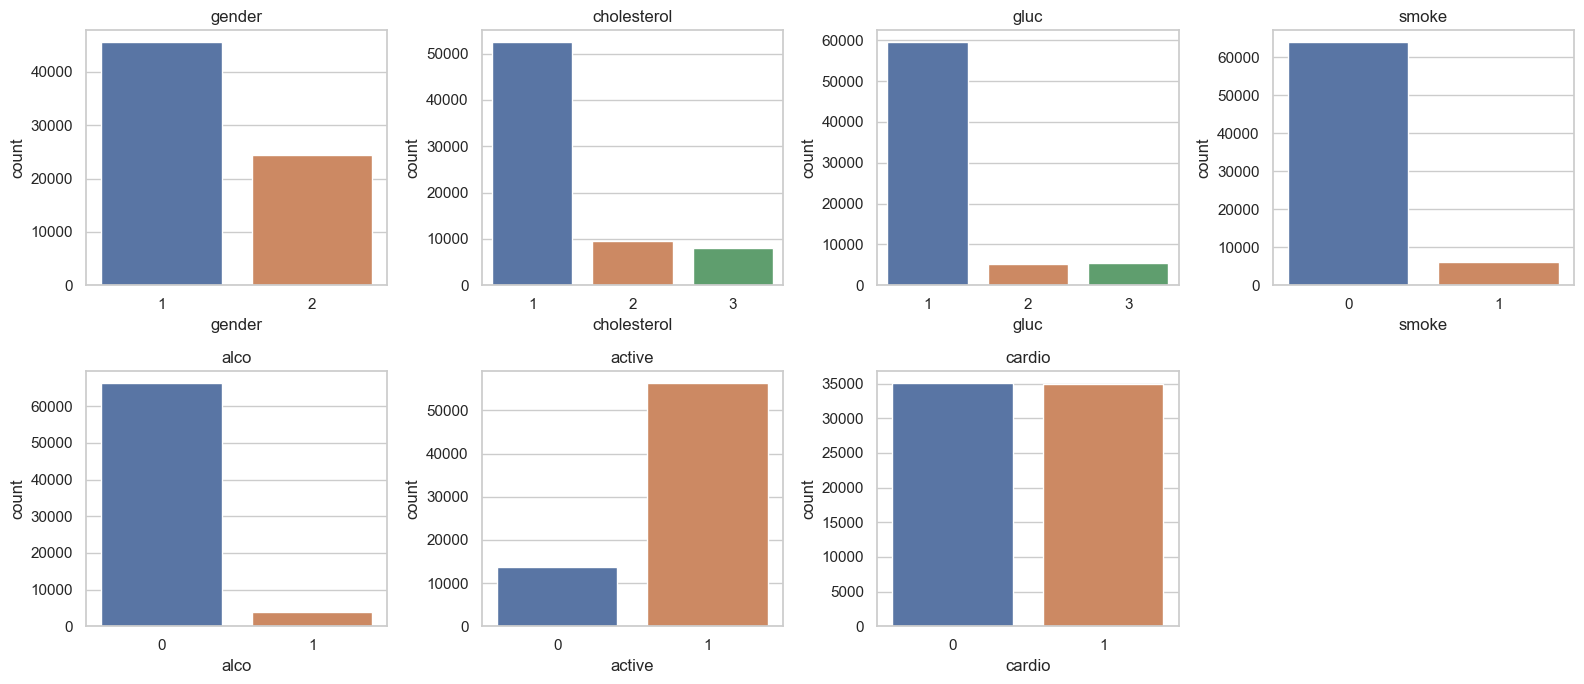

cardio
0    0.5
1    0.5
Name: proportion, dtype: float64


In [17]:
categorical = ["gender", "cholesterol", "gluc", "smoke", "alco", "active", "cardio"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), categorical):
    sns.countplot(x=col, data=df, ax=ax)
    ax.set_title(col)
for ax in axes.ravel()[len(categorical):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Target balance — important to know before modelling
print(df["cardio"].value_counts(normalize=True).round(3))

The target `cardio` is close to a 50/50 split, so accuracy is a reasonable baseline metric and no heavy class re-balancing is needed.

## 7. Clinical sanity checks — the heart of this EDA

This is where a clinical dataset differs from a generic one. We flag rows that are **physiologically impossible**, not just statistically extreme.

In [18]:
# Diastolic should never exceed systolic
bp_inverted = (df["ap_lo"] > df["ap_hi"]).sum()

# Plausible physiological ranges
out_of_range = {
    "ap_hi out of 60-250"   : (~df["ap_hi"].between(60, 250)).sum(),
    "ap_lo out of 40-200"   : (~df["ap_lo"].between(40, 200)).sum(),
    "height out of 120-220" : (~df["height"].between(120, 220)).sum(),
    "weight out of 30-200"  : (~df["weight"].between(30, 200)).sum(),
    "bmi out of 10-60"      : (~df["bmi"].between(10, 60)).sum(),
}

print(f"Rows with diastolic > systolic: {bp_inverted}")
for k, v in out_of_range.items():
    print(f"{k:24s}: {v}")

Rows with diastolic > systolic: 1234
ap_hi out of 60-250     : 228
ap_lo out of 40-200     : 1012
height out of 120-220   : 53
weight out of 30-200    : 7
bmi out of 10-60        : 71


In [19]:
# How extreme? Look at the raw BP range before cleaning.
print("ap_hi range:", df["ap_hi"].min(), "to", df["ap_hi"].max())
print("ap_lo range:", df["ap_lo"].min(), "to", df["ap_lo"].max())

ap_hi range: -150 to 16020
ap_lo range: -70 to 11000


### Apply clinically plausible filters

We build a clean copy rather than mutating in place, and report how many rows we lose. Keep the thresholds visible and easy to tune — they are clinical assumptions, not magic numbers.

In [20]:
before = len(df)
clean = df[
    df["ap_hi"].between(60, 250) &
    df["ap_lo"].between(40, 200) &
    (df["ap_hi"] >= df["ap_lo"]) &
    df["height"].between(120, 220) &
    df["weight"].between(30, 200) &
    df["bmi"].between(10, 60)
].copy()

print(f"Rows before: {before}")
print(f"Rows after : {len(clean)}  ({before - len(clean)} removed, "
      f"{(before - len(clean)) / before:.1%})")

Rows before: 70000
Rows after : 68595  (1405 removed, 2.0%)


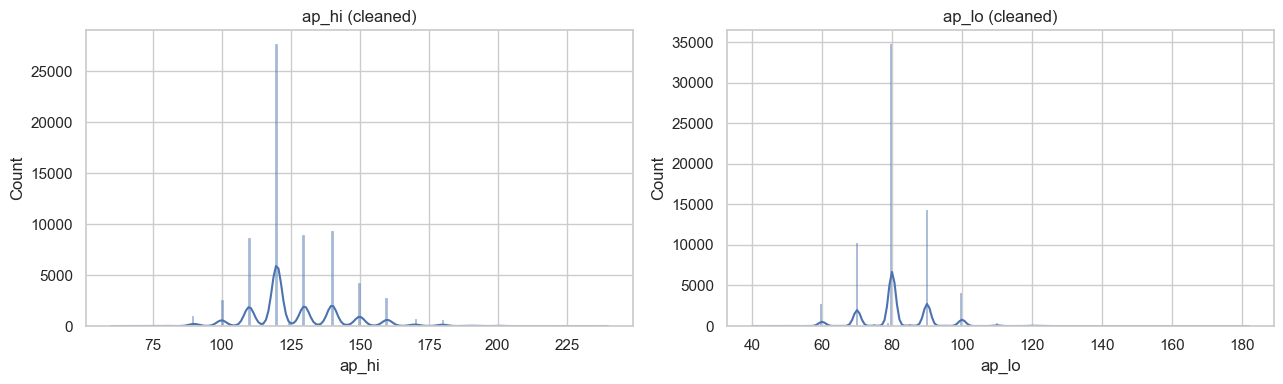

In [21]:
# Re-plot BP now that the impossible values are gone — distributions become legible.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(clean["ap_hi"], kde=True, ax=axes[0]).set_title("ap_hi (cleaned)")
sns.histplot(clean["ap_lo"], kde=True, ax=axes[1]).set_title("ap_lo (cleaned)")
plt.tight_layout()
plt.show()

## 8. Bivariate analysis — relationship to the target `cardio`

### 8a. Continuous features vs. target

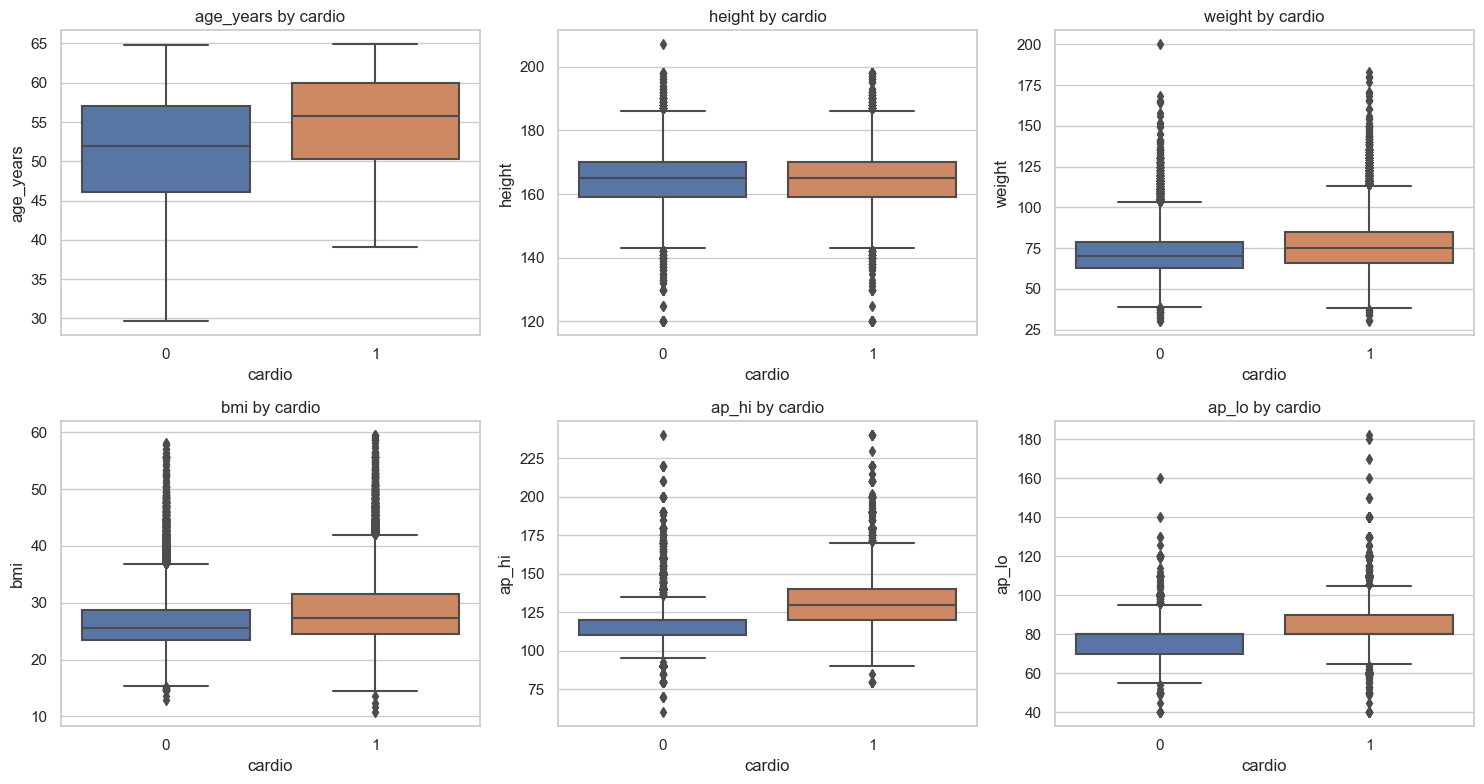

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), ["age_years", "height", "weight", "bmi", "ap_hi", "ap_lo"]):
    sns.boxplot(x="cardio", y=col, data=clean, ax=ax)
    ax.set_title(f"{col} by cardio")
plt.tight_layout()
plt.show()

Expect clear upward shifts for **age**, **systolic BP**, and **BMI** in the `cardio = 1` group — these are the strongest individual predictors and align with clinical intuition.

### 8b. Categorical features vs. target (CVD rate within each group)

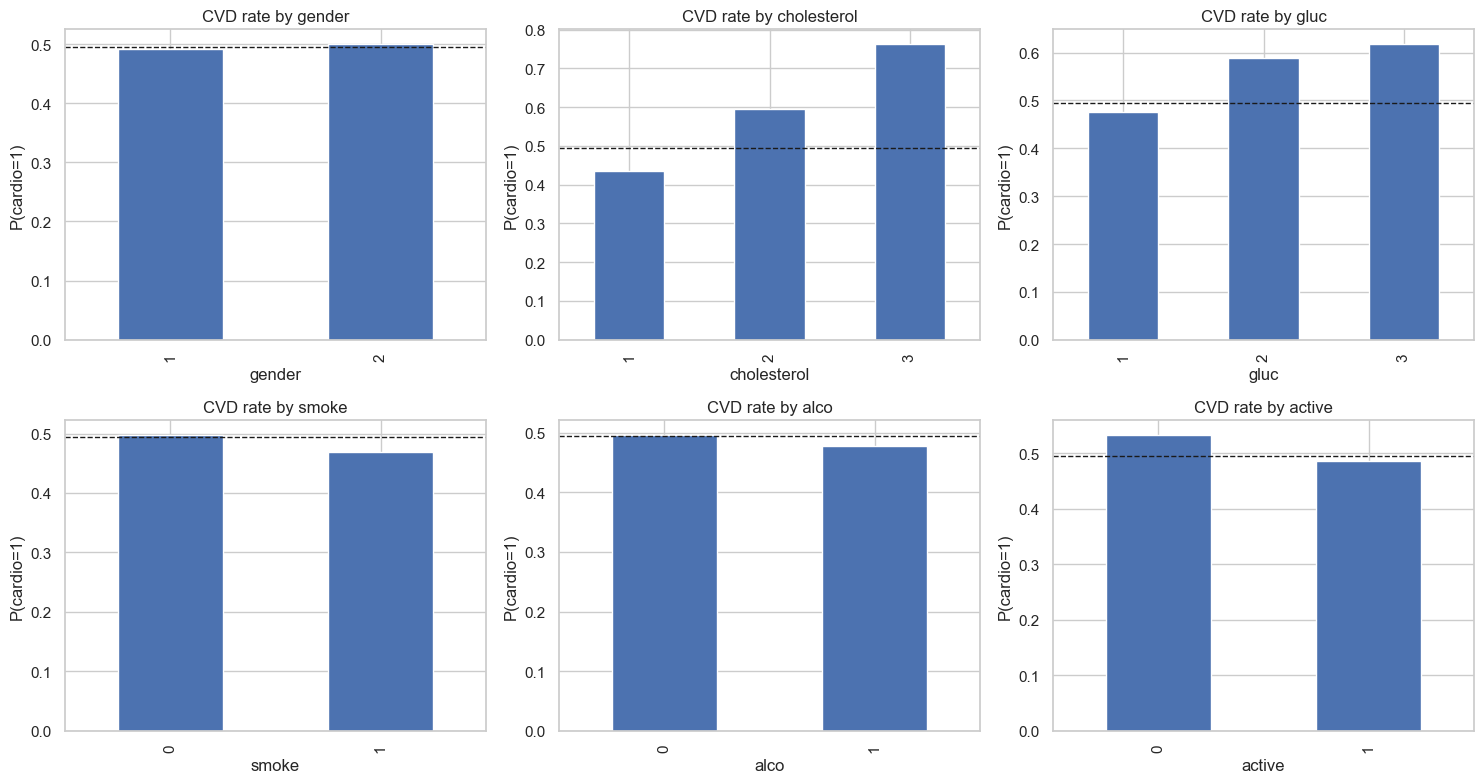

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cat_cols = ["gender", "cholesterol", "gluc", "smoke", "alco", "active"]
for ax, col in zip(axes.ravel(), cat_cols):
    (clean.groupby(col)["cardio"].mean()
          .plot(kind="bar", ax=ax))
    ax.set_title(f"CVD rate by {col}")
    ax.set_ylabel("P(cardio=1)")
    ax.axhline(clean["cardio"].mean(), ls="--", color="k", lw=1)
plt.tight_layout()
plt.show()

The dashed line is the overall CVD rate. Bars well above it (e.g. high `cholesterol`, high `gluc`) flag higher-risk groups; `active = 1` should sit below the line.

## 9. Correlation structure

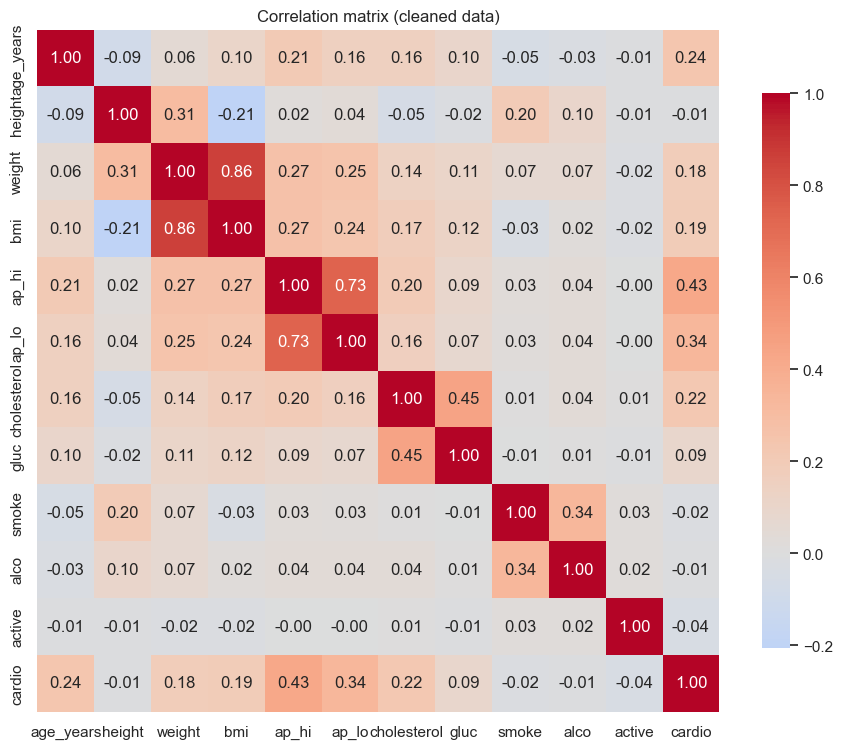

ap_hi          0.428035
ap_lo          0.340080
age_years      0.239476
cholesterol    0.221449
bmi            0.191294
weight         0.181035
gluc           0.089567
alco          -0.008448
height        -0.011704
smoke         -0.016268
active        -0.037703
Name: cardio, dtype: float64


In [24]:
num_cols = ["age_years", "height", "weight", "bmi",
            "ap_hi", "ap_lo", "cholesterol", "gluc",
            "smoke", "alco", "active", "cardio"]

corr = clean[num_cols].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": .8})
plt.title("Correlation matrix (cleaned data)")
plt.show()

# Strongest linear associations with the target
print(corr["cardio"].drop("cardio").sort_values(ascending=False))

`ap_hi` and `ap_lo` will be strongly correlated with each other (multicollinearity to keep in mind for linear models). Against the target, `ap_hi`, `age_years`, and `cholesterol` typically lead.

## 10. Summary & handoff to the pipeline

**Structure.** 70k rows, 13 columns, one row per patient. `id` dropped; `age` converted to years; `bmi` engineered.

**Quality findings.**
- No missing values; check duplicates as shown.
- `ap_hi` / `ap_lo` contain impossible values (negatives, thousands, diastolic > systolic) — the dominant quality issue.
- Minor height/weight/BMI outliers.

**Cleaning rule applied** (tune thresholds with clinical input):
`ap_hi ∈ [60,250]`, `ap_lo ∈ [40,200]`, `ap_hi ≥ ap_lo`, `height ∈ [120,220]`, `weight ∈ [30,200]`, `bmi ∈ [10,60]`.

**Signal.** Target ~balanced. Strongest individual predictors: systolic BP, age, cholesterol, BMI. `active` is protective.

**Next steps for the system:** persist the cleaned frame, encode the ordinal (`cholesterol`, `gluc`) and binary features, watch ap_hi/ap_lo multicollinearity, then move to baseline modelling.

In [26]:
# Persist the cleaned dataset for the next pipeline stage
clean.to_csv("../data/processed/cardio_clean.csv", index=False)
print("Saved cardio_clean.csv:", clean.shape)

Saved cardio_clean.csv: (68595, 17)


## Train/test split and the imputation decision

In [27]:
from sklearn.model_selection import train_test_split

FEATURES = ["age_years", "gender", "height", "weight", "bmi",
            "ap_hi", "ap_lo", "cholesterol", "gluc", "smoke", "alco", "active"]
X = clean[FEATURES]
y = clean["cardio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print("train:", X_train.shape, "| test:", X_test.shape)
print("positive rate  train/test:", round(y_train.mean(), 3), "/", round(y_test.mean(), 3))

train: (54876, 12) | test: (13719, 12)
positive rate  train/test: 0.495 / 0.495


an 80/20 split with `stratify=y` keeps the class ratio identical in both folds. With 70k rows a single held-out test set is large enough to trust (unlike the 300-row heart datasets, which would need k-fold). We split **before** any scaling or imputation so the test set stays a true unseen sample. Model *selection* below uses cross-validation **inside the training set**, leaving the test set for one final unbiased read.

In [28]:
#Let's see if imputation is necessary before we get to modelling.

print("Missing values in train:", int(X_train.isna().sum().sum()))
print("Missing values in test :", int(X_test.isna().sum().sum()))

Missing values in train: 0
Missing values in test : 0


## MODELING - Classification — LogReg, Random Forest, XGBoost, LightGBM

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

numeric = ["age_years", "height", "weight", "bmi", "ap_hi", "ap_lo"]
coded   = ["gender", "cholesterol", "gluc", "smoke", "alco", "active"]

# Scale continuous features (needed by Logistic Regression); pass coded features through.
preprocess = ColumnTransformer(
    [("num", StandardScaler(), numeric),
     ("pass", "passthrough", coded)])

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)
y_pred = model_lr.predict(X_test)   
y_pred_proba = model_lr.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print("-" * 30)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}")

Logistic Regression Results
------------------------------
Accuracy:  0.7306
Precision: 0.7594
Recall:    0.6666
F1 Score:  0.7100
ROC AUC:   0.7938


ROC-AUC 0.7938 is the headline and the most trustworthy figure. It's the probability that the model ranks a random CVD patient as higher-risk than a random healthy one — so ~79% of the time it gets the ordering right.  
Accuracy 0.7306 means ~73% of patients are classified correctly. Because your classes are balanced (~50/50), random guessing would score 50%, so 73% is a real signal, not an artifact of class imbalance.  
Precision 0.76: when the model says "this patient has CVD," it's right ~76% of the time. Relatively few false alarms.
Recall 0.67: of the patients who actually have CVD, the model only catches ~67% — it misses about a third of true cases (false negatives).
F1 0.71 is just the balance point between precision and recall. 

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

RANDOM_STATE = 42

candidates = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "RandomForest":       RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                                 random_state=RANDOM_STATE),
    "XGBoost":            XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                                        tree_method="hist", eval_metric="logloss",
                                        random_state=RANDOM_STATE),
    "LightGBM":           LGBMClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                                         random_state=RANDOM_STATE, verbose=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- Step 1: select the winner using CV on the TRAINING set only ---
cv_scores = {}
for name, est in candidates.items():
    pipe = Pipeline([("prep", preprocess), ("model", est)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_scores[name] = scores.mean()
    print(f"{name:20s} CV ROC-AUC = {scores.mean():.4f} +/- {scores.std():.4f}")

best_name = max(cv_scores, key=cv_scores.get)
print(f"\nSelected by CV: {best_name}")

# --- Step 2: refit the winner on all training data, evaluate ONCE on the test set ---
best_pipe = Pipeline([("prep", preprocess), ("model", candidates[best_name])])
best_pipe.fit(X_train, y_train)

y_pred       = best_pipe.predict(X_test)
y_pred_proba = best_pipe.predict_proba(X_test)[:, 1]

print(f"\n{best_name} — Final Test Results")
print("-" * 36)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}")

LogisticRegression   CV ROC-AUC = 0.7903 +/- 0.0027
RandomForest         CV ROC-AUC = 0.7711 +/- 0.0026
XGBoost              CV ROC-AUC = 0.7965 +/- 0.0033
LightGBM             CV ROC-AUC = 0.7961 +/- 0.0032

Selected by CV: XGBoost

XGBoost — Final Test Results
------------------------------------
Accuracy:  0.7372
Precision: 0.7596
Recall:    0.6859
F1 Score:  0.7209
ROC AUC:   0.8037


four models from simple to complex, each in the *same* pipeline so preprocessing is re-fit per CV fold (no leakage). We rank by **ROC-AUC** rather than accuracy — AUC is threshold-independent and the better summary of ranking quality. Logistic Regression is the interpretable baseline; the gradient-boosted trees (XGBoost, LightGBM) typically win on this dataset because the risk factors interact non-linearly (e.g. age × blood pressure).

In [43]:
from sklearn.metrics import (roc_auc_score, accuracy_score, classification_report,
                             confusion_matrix, RocCurveDisplay)

best = best_pipe                      # the fitted pipeline from methodology 2
proba = best.predict_proba(X_test)[:, 1]
pred  = best.predict(X_test)

print("Best model by CV:", best_name)
print(f"\nTest ROC-AUC : {roc_auc_score(y_test, proba):.4f}")
print(f"Test accuracy: {accuracy_score(y_test, pred):.4f}\n")
print(classification_report(y_test, pred, digits=3))

Best model by CV: XGBoost

Test ROC-AUC : 0.8037
Test accuracy: 0.7372

              precision    recall  f1-score   support

           0      0.719     0.788     0.752      6932
           1      0.760     0.686     0.721      6787

    accuracy                          0.737     13719
   macro avg      0.739     0.737     0.736     13719
weighted avg      0.739     0.737     0.736     13719



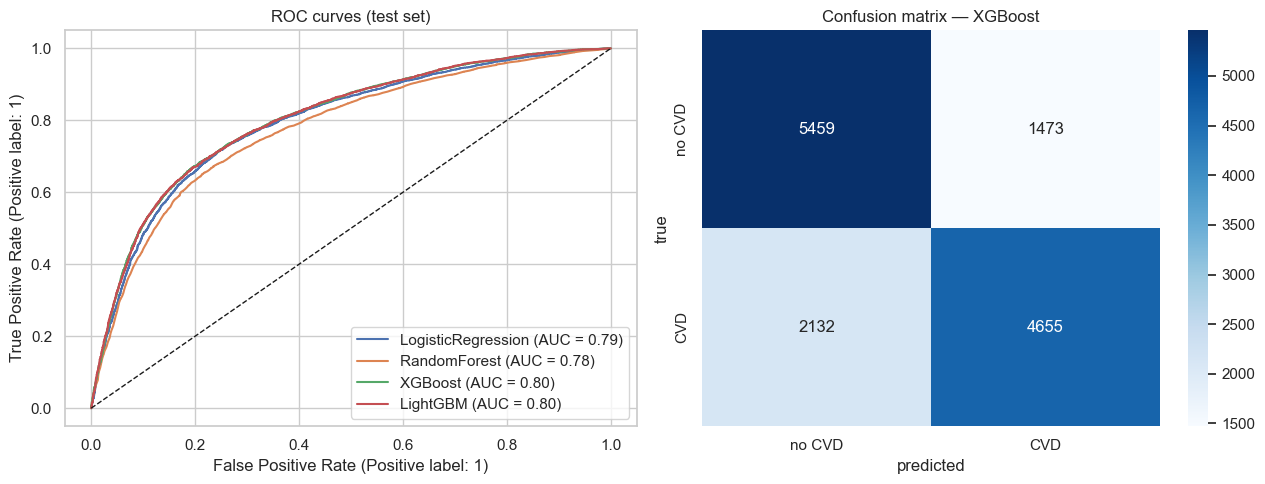

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import RocCurveDisplay, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Build + fit each candidate so we have real estimators to plot.
fitted = {}
for name, est in candidates.items():
    pipe = Pipeline([("prep", preprocess), ("model", est)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for name, pipe in fitted.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax[0], name=name)
ax[0].plot([0, 1], [0, 1], "k--", lw=1)
ax[0].set_title("ROC curves (test set)")

# Confusion matrix for the selected best model (reuse `best` from your previous cell).
pred = best.predict(X_test)
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[1],
            xticklabels=["no CVD", "CVD"], yticklabels=["no CVD", "CVD"])
ax[1].set_title(f"Confusion matrix — {best_name}")
ax[1].set_ylabel("true"); ax[1].set_xlabel("predicted")
plt.tight_layout(); plt.show()

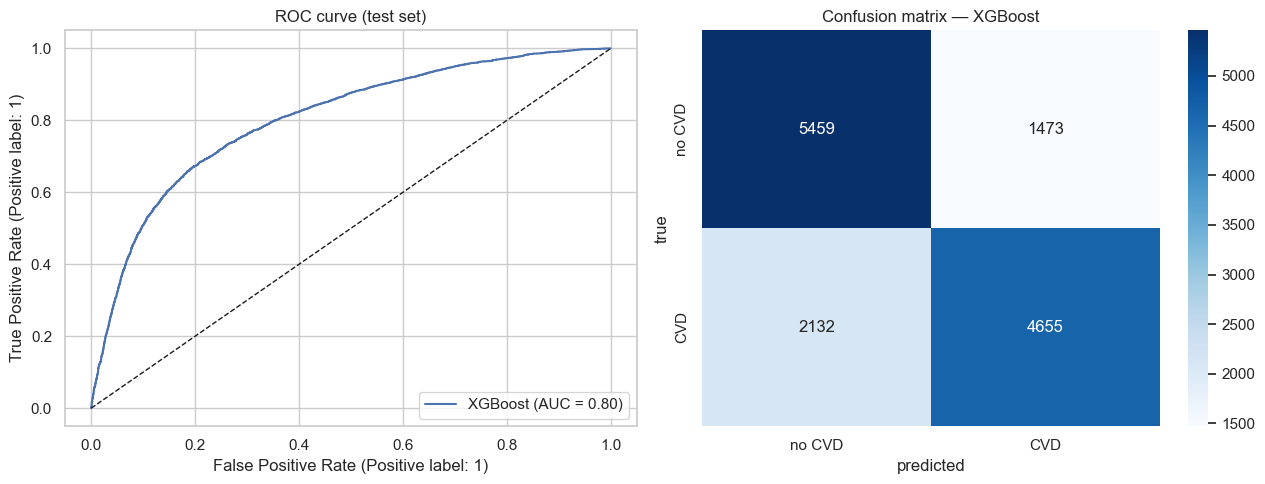

In [46]:
from sklearn.metrics import RocCurveDisplay, confusion_matrix

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
RocCurveDisplay.from_estimator(best, X_test, y_test, ax=ax[0], name=best_name)
ax[0].plot([0, 1], [0, 1], "k--", lw=1)
ax[0].set_title("ROC curve (test set)")

pred = best.predict(X_test)
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[1],
            xticklabels=["no CVD", "CVD"], yticklabels=["no CVD", "CVD"])
ax[1].set_title(f"Confusion matrix — {best_name}")
ax[1].set_ylabel("true"); ax[1].set_xlabel("predicted")
plt.tight_layout(); plt.show()

The curve plots true-positive rate (recall) against false-positive rate as the threshold sweeps from 1 to 0. Higher and more to the left (hugging the top-left corner) is better — that's catching more true cases without raising false alarms. 

## Hyperparameter tuning — RandomizedSearchCV on LightGBM

In [47]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

tune_pipe = Pipeline([("prep", preprocess),
                      ("model", LGBMClassifier(random_state=RANDOM_STATE, verbose=-1))])

# Ranges are prefixed with "model__" to target the classifier inside the pipeline.
param_dist = {
    "model__n_estimators":     randint(200, 700),
    "model__max_depth":        randint(3, 12),
    "model__learning_rate":    uniform(0.01, 0.2),
    "model__num_leaves":       randint(15, 80),
    "model__subsample":        uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4),
    "model__reg_lambda":       uniform(0.0, 5.0),
}

search = RandomizedSearchCV(
    tune_pipe, param_distributions=param_dist,
    n_iter=25, scoring="roc_auc", cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
search.fit(X_train, y_train)

print("Best CV ROC-AUC:", round(search.best_score_, 4))
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k:26s} {round(v, 4) if isinstance(v, float) else v}")

Best CV ROC-AUC: 0.8002
Best params:
  model__colsample_bytree    0.8011
  model__learning_rate       0.0203
  model__max_depth           7
  model__n_estimators        423
  model__num_leaves          15
  model__reg_lambda          1.1978
  model__subsample           0.658


`n_iter=25` samples 25 random configurations (raise it if you have time — more samples, better coverage). We tune the levers that matter most for gradient boosting: tree count and depth/`num_leaves` (capacity), `learning_rate` (step size), `subsample`/`colsample_bytree` (row/column sampling, which fights overfitting), and `reg_lambda` (L2 regularisation). Scoring is ROC-AUC for consistency with the comparison above. The `"model__"` prefix routes each parameter to the classifier step inside the pipeline.

In [48]:
# Compare the tuned model against its default on the held-out test set.
tuned = search.best_estimator_
tuned_auc = roc_auc_score(y_test, tuned.predict_proba(X_test)[:, 1])
default_auc = roc_auc_score(y_test, fitted["LightGBM"].predict_proba(X_test)[:, 1])
print(f"LightGBM default  test ROC-AUC: {default_auc:.4f}")
print(f"LightGBM tuned    test ROC-AUC: {tuned_auc:.4f}")
print(f"Improvement: {tuned_auc - default_auc:+.4f}")

# Adopt the tuned model as the best model if it wins; otherwise keep the prior best.
if tuned_auc >= roc_auc_score(y_test, best.predict_proba(X_test)[:, 1]):
    best, best_name = tuned, "LightGBM (tuned)"
    fitted["LightGBM (tuned)"] = tuned
print("\nBest model going into explainability:", best_name)

LightGBM default  test ROC-AUC: 0.8038
LightGBM tuned    test ROC-AUC: 0.8065
Improvement: +0.0027

Best model going into explainability: LightGBM (tuned)


## Explainability — SHAP

/Users/cosmina/Ginger_Gradient/clinical-intelligence-system/.venv/lib/python3.11/site-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


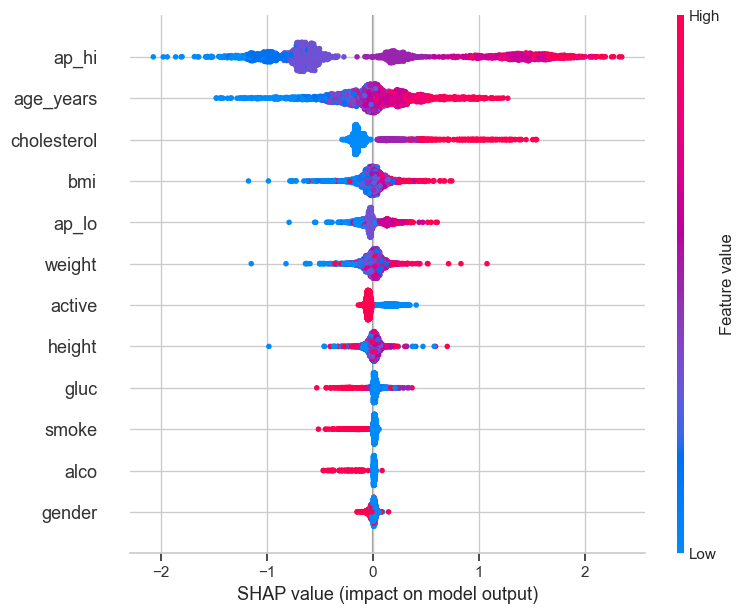

In [49]:
import shap

# Use a tree model for fast, exact SHAP values (TreeExplainer). Pick the best tree model.
tree_name = best_name if best_name in ("RandomForest", "XGBoost", "LightGBM") else "LightGBM"
tree_pipe = fitted[tree_name]

# Transform a sample of the test set through the SAME preprocessing the model saw.
sample = X_test.sample(min(2000, len(X_test)), random_state=RANDOM_STATE)
sample_prep = tree_pipe.named_steps["prep"].transform(sample)
feat_names = numeric + coded

explainer = shap.TreeExplainer(tree_pipe.named_steps["model"])
shap_values = explainer.shap_values(sample_prep)
# Some models return a list (per class); take the positive class.
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(sv, sample_prep, feature_names=feat_names, show=True)

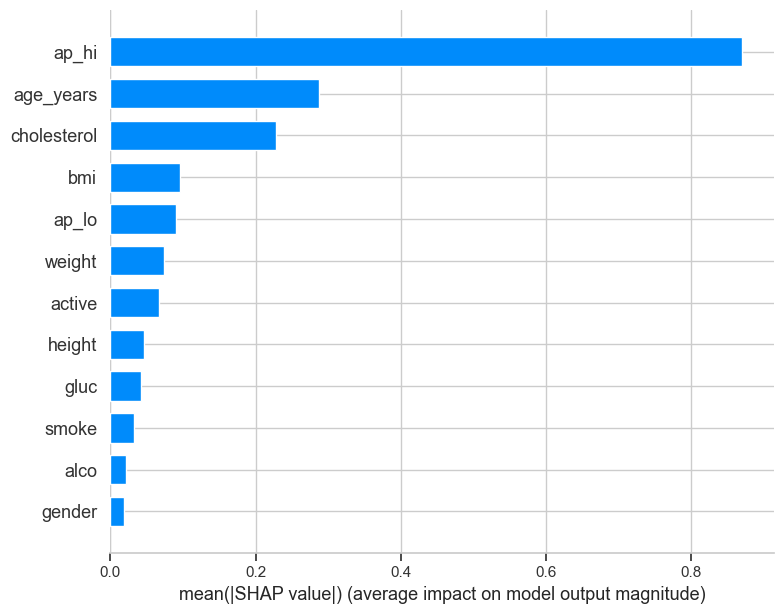

In [50]:
shap.summary_plot(sv, sample_prep, feature_names=feat_names, plot_type="bar", show=True)

SHAP explains *why* the model predicts what it does, which is essential for a clinical tool — a black-box risk score is not actionable. We use `TreeExplainer` (exact and fast for tree models) on a 2000-row sample, transformed through the model's own preprocessing so the feature space matches. The **beeswarm** shows each feature's direction and magnitude of effect per patient; the **bar** plot is the global ranking. Expect `ap_hi`, `age_years`, `cholesterol`, and `bmi` at the top — and reassuringly, high values push toward disease (red = high feature value sitting on the positive-SHAP side), which agrees with clinical knowledge.